# Day 2 — Excursion to PDE Theory

*Prof. Peter Bastian, slides 33–55. This notebook follows the lecture slide by slide, in plain language, with runnable code for the key ideas.*

### Plan for the lecture (slide 34)

- Introduce **boundary conditions**
- Get a grasp on **PDE theory**
- Understand **well-posedness**
- Know about the **classical types** of PDEs
- Get to know the concept of **weak solutions**


### My notes from class

```
Day 2 — Mass theorem etc.

PDE theory:  linear | non-linear
   i) unique     -> yes, determine it
  ii) stable

ODE situation:
   i) Peano existence theorem  [t0, t0+delta]
  ii) Picard–Lindelöf,  Lipschitz-continuous,  delta = T - t0

Millennium Prize problem on Navier–Stokes -> prove / counter-example
Operator, 4 types

   Delta psi = 4 pi gamma rho  in Omega
   d^2 psi/dx1^2 + d^2 psi/dx2^2 + d^2 psi/dx3^2 = 4 pi gamma rho
   we call this a STRONG solution

Boundary condition:  psi = g(x),  Delta psi = f,  d/dn psi = j(x),  no boundary condition
Well-posedness -> existence -> uniqueness -> stability
Is there always a unique solution in a bounded domain?  Does every problem have boundary conditions?

Type classification (second-order linear):
   a11 d^2_x1 u + 2 a12 d^2_x1x2 u + a22 d^2_x2 u + b1 d_x1 u + b2 d_x2 u + c = f      R x R -> R
   -> elliptic   if eigenvalues of A = [[a11,a12],[a12,a22]] are nonzero and have the SAME sign  (Poisson)
   -> hyperbolic if eigenvalues are nonzero and have OPPOSITE sign  (wave equation)
   -> parabolic  if ONE eigenvalue is zero and [[a11,a12,b1],[a12,a22,b2]] has full rank  (heat equation)

From now on: elliptic condition
   -div(A grad u) = f       positive definite matrix:  a_min <= x^T A x <= a_max
   Dirichlet & Neumann boundary conditions

Lebesgue space:
   measuring convergence of a sequence of functions requires a norm  -> L^2-norm
   ||u||_{0,Omega} = sqrt( int_Omega u^2(x) dx )
   ||u||_{0,Omega} = sqrt( (u,u)_{0,Omega} )  with scalar product  (u,v)_{0,Omega} = int_Omega u v dx
   L^2(Omega) is a HILBERT space: complete, linear space with scalar product

Sobolev spaces:
   u in C^1(Omega),  define H^1 scalar product
   (u,v)_{1,Omega} = int_Omega u v + sum_{i=1}^d d_xi u d_xi v dx
   H^k_0(Omega) subset H^k(Omega) is the subspace of functions that are zero on dOmega

Weak solution concept (Green's 1st theorem):
   -div(A grad u) = f  in Omega
   -int_Omega div(A grad u) v dx = int_Omega (A grad u).grad v dx + int_dOmega (-A grad u).n v ds = int_Omega f v dx
   - Dirichlet boundary
   - Neumann

Weak formulation:
   a(u,v) = int_Omega (A grad u).grad v dx
   l(v)   = int_Omega f v dx - int_{Gamma_N} j v ds
   a(u,v) is a BILINEAR form and l(v) a LINEAR form

Lax–Milgram theorem:
   a is coercive, i.e. exists alpha > 0 : alpha ||v||^2_V <= a(v,v)
   the bilinear form a(u,v) = int_Omega (A grad u).grad v dx

Application of Lax–Milgram:  weak formulation, re-entrant corner problem
   weak solution <- strong solution
```


## 1. Motivation (slide 35)

We derived or mentioned several PDEs this week:

- **Poisson's equation** $\Delta\Psi = 4\pi\gamma\rho$
- **Heat equation** $\partial_t(\rho c T) + \nabla\cdot(\rho c T v - \lambda\nabla T) + r\rho c T = f$
- Euler equations, Navier–Stokes equations, groundwater flow, …

They have different properties:

- **Linear vs. nonlinear.** Linear means superposition works: if $\Delta\Psi_1 = f_1$ and $\Delta\Psi_2 = f_2$ then $\Delta(\alpha_1\Psi_1 + \alpha_2\Psi_2) = \alpha_1 f_1 + \alpha_2 f_2$.
- **Stationary vs. instationary** (time-dependent or not).

The four questions that drive the whole lecture:

1. **Does a given PDE have a solution?**
2. **If yes, is it unique?**
3. **If yes, is it stable?**
4. **If yes, how can we determine it?**


## 2. The situation in ODEs — and why PDEs are harder (slide 36)

For ordinary differential equations there are clean, general answers (exactly what Dr. Winckler covered on Day 2 of the ODE series):

**Peano's existence theorem.** Let $f : [t_0,T]\times\mathbb{R}^d \to \mathbb{R}^d$ be *continuous*. Then the initial value problem
$$\frac{dy}{dt}(t) = f(t,y(t)), \qquad y(t_0) = y_0$$
has a solution in $[t_0, t_0+\delta)$.

**Picard–Lindelöf.** If in addition $f$ is **Lipschitz-continuous** in its second argument, the solution is **unique** and $\delta = T - t_0$ (it exists on the whole interval).

> **There is no such general theorem for partial differential equations!**
> Statements are only possible for certain **types** (classes) of equations.

That single sentence is why the rest of the lecture is about *classifying* PDEs and then treating one class properly.


## 3. How hard can it get? The Millennium Prize problem (slide 37)

PDE theory can be genuinely difficult. One of the seven **Millennium Prize Problems** of the Clay Institute (announced 24 May 2000):

> *Prove or give a counter-example of the following statement:* in three space dimensions and time, given an initial velocity field, there exists a vector velocity and a scalar pressure field, which are both smooth and globally defined, that solve the Navier–Stokes equations.

Still open. (Slide note: OpenAI claims one of its AIs has found a counter-example — treat that as unconfirmed.)

So we begin much more modestly, with Poisson's equation.


## 4. What *is* a solution? The strong solution (slide 38)

Consider Poisson's equation in a **bounded domain** $\Omega \subset \mathbb{R}^3$:

$$\Delta\Psi = 4\pi\gamma\rho \quad \text{in } \Omega$$

This means $\Psi(x_1,x_2,x_3)$ satisfies, **at every single point**,

$$\forall x \in \Omega: \qquad \frac{\partial^2\Psi}{\partial x_1^2}(x) + \frac{\partial^2\Psi}{\partial x_2^2}(x) + \frac{\partial^2\Psi}{\partial x_3^2}(x) = 4\pi\gamma\rho(x)$$

We call this a **strong solution** (later there will be a **weak** solution).

- $\Psi$ must be at least **twice continuously differentiable** in each variable: $\Psi \in C^2(\Omega)$.
- This also implies $\rho$ should be **continuous** — a demand on the *data*, which is where the trouble starts.
- $\Omega$ is an **open** set, e.g. $\Omega = \{x : \|x\| < 1\}$. The boundary $\partial\Omega = \{x : \|x\| = 1\}$ is **not** included in the statement — which is exactly why we need boundary conditions next.


## 5. Boundary conditions (slide 39)

What do we do at the boundary of a bounded domain? **We need a boundary condition** — compare with the initial condition for an ODE.

**Why:** let $\Psi$ solve $\Delta\Psi = 4\pi\gamma\rho$ in $\Omega$. Then $\Psi + 1$, or $\Psi + 2x_1 - 3x_2 + 7$, are **also solutions** — the Laplacian annihilates constants and linear functions. Without boundary conditions, solutions of PDEs are often **not unique**; boundary conditions restore uniqueness.

Different conditions are possible for Poisson's equation:

| name | condition | meaning |
|---|---|---|
| **Dirichlet** | $\Psi(x) = g(x)$ for $x\in\partial\Omega$ | the value is prescribed |
| **Neumann** | $\nabla\Psi(x)\cdot n(x) = j(x)$ for $x\in\partial\Omega$ | the flux is prescribed ($n$ = unit outer normal) |
| **Mixed** | Dirichlet on part, Neumann on the rest | |

Let's verify the non-uniqueness claim numerically.


In [1]:
import numpy as np, matplotlib.pyplot as plt


In [2]:
# A. WITHOUT BOUNDARY CONDITIONS THE SOLUTION IS NOT UNIQUE   (slide 39)
#    If Delta(Psi) = f then Psi + 1 and Psi + 2x1 - 3x2 + 7 solve it too,
#    because the Laplacian kills constants and linear functions.
# =============================================================================
x = np.linspace(-1, 1, 200); X, Y = np.meshgrid(x, x)
Psi   = lambda X, Y: 0.25*(X**2 + Y**2)                 # Delta Psi = 1
lap = lambda F: (np.gradient(np.gradient(F, x, axis=1), x, axis=1)
               + np.gradient(np.gradient(F, x, axis=0), x, axis=0))
for name, F in [("Psi", Psi(X, Y)), ("Psi + 1", Psi(X, Y) + 1),
                ("Psi + 2x1 - 3x2 + 7", Psi(X, Y) + 2*X - 3*Y + 7)]:
    print(f"A.  Laplacian of ({name:22s}) = {lap(F)[5:-5, 5:-5].mean():.6f}   (all give f = 1)")


A.  Laplacian of (Psi                   ) = 1.000000   (all give f = 1)
A.  Laplacian of (Psi + 1               ) = 1.000000   (all give f = 1)
A.  Laplacian of (Psi + 2x1 - 3x2 + 7   ) = 1.000000   (all give f = 1)


## 6. Well-posedness (slide 40)

A PDE problem is **well-posed in the sense of Hadamard** if it has:

1. **existence** — it has a solution;
2. **uniqueness** — the solution is unique;
3. **stability** — the solution depends *continuously* on the data (boundary conditions, parameters in the PDE, source term, …).

- Boundary conditions are often needed to ensure **uniqueness**.
- The *kind* of boundary condition, and *where* it is posed, is often determined by **stability**.

Stability matters in practice: data always carry measurement error, and a problem where a tiny data change produces a huge solution change is useless even if a unique solution exists.

### Examples of boundary conditions (slide 41)

Two pictures from the lecture:

- **Square domain, $\Delta\Psi = f$:** Dirichlet $\Psi = g$ on the left edge; Neumann $\partial_{x_1}\Psi = j$ on the right; a mixture on top; and on the bottom **no boundary condition** — which is fine for some equations and fatal for others.
- **Disc, $1\cdot\partial_{x_1}u + 1\cdot\partial_{x_2}u = f$** (a first-order transport equation): the condition $\Psi = g$ is imposed only on the **inflow** part of the boundary
  $$\partial\Omega_{in} = \{(x_1,x_2)\in\partial\Omega : 1\cdot x_1 + 1\cdot x_2 < 0\}$$
  On the outflow half, **no boundary condition** may be imposed — the solution is already determined by what flowed in. Prescribing one there makes the problem ill-posed.

That answers the questions in my notes: *no*, not every problem has boundary conditions on the whole boundary, and *where* they may be posed depends on the equation's type.


## 7. Type classification (slide 42)

A **second-order linear** PDE in two variables for $u:\mathbb{R}\times\mathbb{R}\to\mathbb{R}$:

$$a_{11}\partial^2_{x_1x_1}u + 2a_{12}\partial^2_{x_1x_2}u + a_{22}\partial^2_{x_2x_2}u + b_1\partial_{x_1}u + b_2\partial_{x_2}u + c = f$$

Everything hinges on the eigenvalues of the coefficient matrix $A = \begin{pmatrix} a_{11} & a_{12} \\ a_{12} & a_{22}\end{pmatrix}$:

| type | condition on eigenvalues | canonical example |
|---|---|---|
| **elliptic** | nonzero, **same sign** | $\partial^2_{x_1}u + \partial^2_{x_2}u = f$ (Poisson) |
| **hyperbolic** | nonzero, **opposite sign** | $\partial^2_{x_1}u - \partial^2_{x_2}u = f$ (wave) |
| **parabolic** | **one** eigenvalue zero, and $\begin{pmatrix} a_{11} & a_{12} & b_1 \\ a_{12} & a_{22} & b_2\end{pmatrix}$ has full rank | $\partial_{x_1}u - \partial^2_{x_2}u = f$ (heat) |

**Each type needs separate treatment in theory and numerics** — different boundary conditions, different well-posedness theory, different numerical methods. That is the answer to "why is there no general theorem".


In [3]:
# B. TYPE CLASSIFICATION FROM THE EIGENVALUES OF A            (slide 42)
#    a11 u_xx + 2 a12 u_xy + a22 u_yy + ... = f
# =============================================================================
def classify(a11, a12, a22, b1=0.0, b2=0.0):
    A = np.array([[a11, a12], [a12, a22]])
    ev = np.linalg.eigvalsh(A)
    if np.all(np.abs(ev) > 1e-12):
        return ("elliptic" if ev[0]*ev[1] > 0 else "hyperbolic"), ev
    M = np.array([[a11, a12, b1], [a12, a22, b2]])         # parabolic needs full rank
    return ("parabolic" if np.linalg.matrix_rank(M) == 2 else "degenerate"), ev

print()
for name, args in [("Poisson  u_xx + u_yy = f", (1, 0, 1)),
                   ("wave     u_xx - u_yy = f", (1, 0, -1)),
                   ("heat     u_x  - u_yy = f", (0, 0, -1, 1, 0)),
                   ("rotated anisotropic    ", (3, 1, 2))]:
    t, ev = classify(*args)
    print(f"B.  {name}  eigenvalues {np.round(ev, 3)}  ->  {t}")



B.  Poisson  u_xx + u_yy = f  eigenvalues [1. 1.]  ->  elliptic
B.  wave     u_xx - u_yy = f  eigenvalues [-1.  1.]  ->  hyperbolic
B.  heat     u_x  - u_yy = f  eigenvalues [-1.  0.]  ->  parabolic
B.  rotated anisotropic      eigenvalues [1.382 3.618]  ->  elliptic


The classification is a two-line eigenvalue computation. Note the last row: a PDE with mixed derivatives can still be elliptic — the *type* is a property of the eigenvalues, not of how the equation looks.

## 8. Linear second-order elliptic PDE (slide 43)

From now on the lecture concentrates on the **linear, second-order, elliptic** PDE

$$-\nabla\cdot(A\nabla u) = f \quad\text{in } \Omega \subseteq \mathbb{R}^d, \quad d = 2,3$$

where $A \in \mathbb{R}^{d\times d}$ is **symmetric** and satisfies

$$a_{min} \le x^T A x \le a_{max} \qquad \forall x\in\mathbb{R}^d,\ x\neq 0$$

for two numbers $0 < a_{min} < a_{max}$.

- $A$ symmetric and **positive definite** ⟹ all eigenvalues real and positive. This *is* ellipticity, now stated in a way that works in any dimension $d > 2$.
- The bounds $a_{min}, a_{max}$ are what make the theory work later — they become the coercivity and continuity constants in Lax–Milgram.

Boundary conditions:

$$u(x) = g(x) \ \text{ on } \Gamma_D \subset \partial\Omega, \qquad -(A\nabla u)\cdot n = j(x) \ \text{ on } \Gamma_N = \partial\Omega\setminus\Gamma_D$$


## 9. The weak solution concept (slides 44–45)

**Step 1 — start from a strong solution.** Assume $u$ solves $-\nabla\cdot(A\nabla u) = f$ in $\Omega$, and let $v \in C^1(\bar\Omega)$ be an arbitrary function (a **test function**). Multiply by $v$, integrate, and apply **integration by parts (Green's 1st theorem)**:

$$-\int_\Omega \nabla\cdot(A\nabla u)\,v\,dx = \int_\Omega (A\nabla u)\cdot\nabla v\,dx + \int_{\partial\Omega} (-A\nabla u)\cdot n\,v\,ds = \int_\Omega f v\,dx$$

The boundary integral is then handled by the two kinds of boundary:

- **Dirichlet boundary** $x\in\Gamma_D$: choose $v(x) = 0$ there, so the term vanishes.
- **Neumann boundary** $x\in\Gamma_N$: insert the boundary condition $-(A\nabla u)\cdot n = j(x)$.

**Step 2 — the result.** For any $v\in C^1(\bar\Omega)$ with $v = 0$ on $\Gamma_D$:

$$\int_\Omega (A\nabla u)\cdot\nabla v\,dx = \int_\Omega f v\,dx - \int_{\Gamma_N} j v\,ds$$

The test function $v$ acts as a **filter**, testing the solution on $\omega = \operatorname{supp}(v) = \overline{\{x : v(x)\neq 0\}}$.

**Step 3 — reverse the argument.** *If we choose a proper set of test functions $V$ and require the identity above for all $v\in V$, does this fix $u$ in some appropriate set $U$ in a unique way?*

**Yes!** But what are the appropriate $U$ and $V$? Answering that needs two new function spaces.

Notice what has been gained: only **first** derivatives of $u$ appear, and only under an integral. The demand $u\in C^2$ is gone.


## 10. Lebesgue space $L^2$ (slide 46)

Measuring convergence of a sequence of functions requires a **norm**, and it should use **integrals** (because the weak form uses integrals). For $u \in C^0(\bar\Omega)$ define the **$L^2$-norm**

$$\|u\|_{0,\Omega} = \sqrt{\int_\Omega u^2(x)\,dx}$$

**The problem:** $C^0(\bar\Omega)$ is **not complete** with respect to this norm — limits of Cauchy sequences may not be continuous functions.

**The remedy:** define $L^2(\Omega)$ as the **completion** of $C^0(\bar\Omega)$ with respect to $\|\cdot\|_{0,\Omega}$. (This requires a proper definition of the Lebesgue integral.)

$$\|u\|_{0,\Omega} = \sqrt{(u,u)_{0,\Omega}} \quad\text{with the } L^2\textbf{-scalar product}\quad (u,v)_{0,\Omega} = \int_\Omega u v\,dx$$

$L^2(\Omega)$ is a **Hilbert space**: a normed, complete, linear space with a scalar product.

Let's *see* the incompleteness — this is the whole reason $L^2$ has to be introduced.


In [4]:
# C. WHY WE NEED L^2: C^0 IS NOT COMPLETE                     (slide 46)
#    A Cauchy sequence of CONTINUOUS functions whose limit is DISCONTINUOUS.
#    u_n = a ramp of width 1/n at x = 0 on Omega = (-1, 1).
# =============================================================================
def u_n(t, n):  return np.clip(n*t, -1, 1)
def L2(f, a=-1, b=1, m=200001):
    t = np.linspace(a, b, m); return np.sqrt(np.trapezoid(f(t)**2, t))

print()
print(f"C.  {'n, m':>12} {'||u_n - u_m||_0':>17}   (Cauchy: the gap goes to 0)")
for n, m in [(10, 20), (100, 200), (1000, 2000), (10000, 20000)]:
    d = L2(lambda t: u_n(t, n) - u_n(t, m))
    print(f"C.  {f'{n}, {m}':>12} {d:>17.3e}")
sgn = lambda t: np.sign(t)
print(f"C.  limit is sign(x), which is NOT continuous;  ||u_n - sign||_0 -> "
      f"{L2(lambda t: u_n(t, 10000) - sgn(t)):.3e}")
print("C.  => C^0 is not complete in ||.||_0 ; L^2 is defined as its completion.")



C.          n, m   ||u_n - u_m||_0   (Cauchy: the gap goes to 0)
C.        10, 20         1.291e-01
C.      100, 200         4.082e-02
C.    1000, 2000         1.291e-02
C.  10000, 20000         4.123e-03
C.  limit is sign(x), which is NOT continuous;  ||u_n - sign||_0 -> 7.550e-03
C.  => C^0 is not complete in ||.||_0 ; L^2 is defined as its completion.


The gap $\|u_n - u_m\|_0 \to 0$, so the sequence is **Cauchy** — but every $u_n$ is continuous while the limit $\operatorname{sign}(x)$ is not. The sequence "converges to something outside the space". Completing $C^0$ by adding all such limits is exactly what $L^2$ is.

## 11. Sobolev spaces (slide 47)

The weak solution concept involves **derivatives** under the integral too, so $L^2$ alone is not enough. For $u\in C^1(\bar\Omega)$ define the **$H^1$-scalar product**

$$(u,v)_{1,\Omega} = \int_\Omega uv + \sum_{i=1}^{d}\partial_{x_i}u\,\partial_{x_i}v \,dx$$

which induces the **$H^1$-norm** $\|u\|_{1,\Omega} = \sqrt{(u,u)_{1,\Omega}}$.

- The **Sobolev space** $H^1(\Omega)$ is the completion of $C^1(\bar\Omega)$ with respect to $\|\cdot\|_{1,\Omega}$.
- This requires a proper extension of derivatives to Sobolev functions (the **weak derivative**).
- $H^k(\Omega)$, $k>1$, involves $k$-th order derivatives; every $H^k(\Omega)$ is a **Hilbert space**.
- $H^k_0(\Omega) \subset H^k(\Omega)$ is the subspace of functions which are **zero on $\partial\Omega$** (almost everywhere).

In one line: $L^2$ = "square-integrable", $H^1$ = "square-integrable **with** a square-integrable gradient", $H^1_0$ = the same but vanishing on the boundary.


## 12. The weak formulation (slide 48)

It turns out that $H^1(\Omega)$ and subspaces of it are the appropriate function spaces for weak solutions. Define

$$a(u,v) = \int_\Omega (A\nabla u)\cdot\nabla v\,dx, \qquad \ell(v) = \int_\Omega f v\,dx - \int_{\Gamma_N} j v\,ds$$

$a(u,v)$ is a **bilinear form** (linear in each argument separately) and $\ell(v)$ is a **linear form**.

For the **homogeneous Dirichlet problem** $\Gamma_D = \partial\Omega$, $u(x) = 0$ on $\partial\Omega$, the weak formulation reads:

$$\boxed{\ \text{Find } u\in H^1_0(\Omega) \text{ s.t. } \quad a(u,v) = \ell(v) \quad \forall v\in H^1_0(\Omega)\ }$$

Other boundary conditions require different subspaces of $H^1(\Omega)$.

Note the elegance: the Dirichlet condition is built into the *space* ($H^1_0$), while the Neumann condition appears in the *right-hand side* $\ell$. That's the essential/natural distinction.


## 13. The Lax–Milgram theorem (slide 49)

**Assumptions:**

- $V$ a real **Hilbert space** with norm $\|\cdot\|_V$ implied by a scalar product $(\cdot,\cdot)_V$;
- $\ell : V\to\mathbb{R}$ a **continuous linear form**, i.e. $\ell(v) \le C_\ell\|v\|$;
- $a : V\times V\to\mathbb{R}$ a **continuous bilinear form**, i.e. $a(u,v)\le C_a\|u\|_V\|v\|_V$;
- $a$ is **coercive**, i.e. $\exists\,\alpha > 0 : \alpha\|v\|_V^2 \le a(v,v)$ for all $v\in V$.

**Then there exists a unique $u\in V$ such that**

$$a(u,v) = \ell(v) \qquad \forall v\in V$$

**Moreover** $\;\|u\|_V \le C_\ell/\alpha$.

That last inequality is **stability**: bound the data ($C_\ell$) and you bound the solution. So Lax–Milgram delivers all three Hadamard requirements — existence, uniqueness, stability — in one theorem.

**Remark from the slide:** the bilinear form $a(u,v) = \int_\Omega(A\nabla u)\cdot\nabla v\,dx$ **is** coercive in $V = H^1_0(\Omega)$. (Continuity comes from $a_{max}$ and Cauchy–Schwarz; coercivity from $a_{min}$ together with the Poincaré inequality — this is where the ellipticity bounds of §8 pay off.)

### Applications of Lax–Milgram (slide 50)

LM can be used to show **well-posedness** of:

- elliptic PDEs with Dirichlet, Neumann and mixed boundary conditions;
- equations including a **sink term** such as $-\nabla\cdot(A\nabla u) + ku = f$ with $k \ge 0$;
- equations including a **convective part** as in $-\nabla\cdot(A\nabla u) + \beta\cdot\nabla u = f$.

Two important caveats:

- Coercivity is a **sufficient** condition for well-posedness, **not necessary**.
- **Symmetry of the bilinear form is not required.**

For the general case with Banach spaces $U, V$ — find $u\in U$ s.t. $a(u,v) = \ell(v)\ \forall v\in V$ — the **Banach–Nečas–Babuška** theorem can be used instead. It works in the parabolic case too.


## 14. Why is this important? (1) — the data (slide 51)

Proving well-posedness of **strong** solutions requires **more assumptions on the data**.

Example: Poisson's equation $\Delta\Psi = 4\pi\gamma\rho$ with

$$\rho(x) = \begin{cases} 1 & \|x\| \le R \\ 0 & \text{else}\end{cases}$$

— a ball of uniform density, i.e. the most natural physical example imaginable.

- For a **strong** solution, discontinuous $\rho$ is **not allowed**; it turns out not even simple continuity is sufficient.
- For the **weak** solution, discontinuous $\rho$ is **perfectly fine**. Only $\rho \in L^2(\Omega)$ is required.
- One can also show: if the weak solution turns out to be in $C^2(\Omega)\cap C^0(\bar\Omega)$ (for the Dirichlet problem), then it **is** a strong solution.

So the weak concept is a strict enlargement: it never loses a classical solution, and it covers data that the classical theory cannot touch. This is precisely the two-sphere gravity example from Day 1.


## 15. Why is this important? (2) — the re-entrant corner (slides 52–53)

Consider $\Delta u = 0$ in the L-shaped domain $\Omega = (-1,1)^2 \setminus ([0,1)\times(-1,0])$. One can show that

$$u(r,\theta) = r^{2/3}\sin\!\Big(\frac{2}{3}\theta\Big)$$

is a solution, expressed **in polar coordinates**. Its properties:

- $u \in C^2(\Omega)\cap C^0(\bar\Omega)$ — it **is** a strong solution in the open domain;
- $u = 0$ at $\{x\in\partial\Omega : \|x\| < 1\}$ (the two edges meeting at the corner);
- **but** $\lim_{r\to 0}\partial_r u(r,\theta) = \infty$ — the gradient blows up at the corner;
- $u\in L^2(\Omega)$, $u\in H^1(\Omega)$, **$u \notin H^2(\Omega)$**.

**Why these singular solutions matter in practice (slide 53):**

- Application: deformation of a **rubber sheet under its own weight**, fixed at the boundary.
- **Large forces near the corners in non-convex domains may lead to rupture** — this is why stress concentration at notches is an engineering concern.
- **It is challenging to compute such solutions accurately** — which is the motivation for the adaptive mesh refinement on Day 3.

Let's verify $u\in H^1$ but $u\notin H^2$ by direct integration.


In [5]:
# D. THE REENTRANT CORNER: u in H^1 but NOT in H^2            (slides 52-53)
#    u = r^(2/3) sin(2 theta / 3)  on the L-shape.  Integrate over an annulus
#    eps < r < 1 and let eps -> 0.
# =============================================================================
alpha = 2/3
# |grad u|^2 = alpha^2 r^(2 alpha - 2);  |D^2 u|^2 ~ C r^(2 alpha - 4)
# integral over the sector of opening 3pi/2:  int_eps^1 r^(2a-2) r dr  and  r^(2a-4) r dr
def energy(eps, p):        # int_eps^1 r^p * r dr  with p = 2a-2 (H1) or 2a-4 (H2)
    q = p + 1
    return (1 - eps**(q+1)) / (q+1) if q != -1 else -np.log(eps)

print()
print(f"D.  {'eps':>8} {'int |grad u|^2 (H1)':>21} {'int |D^2 u|^2 (H2)':>21}")
for eps in [1e-1, 1e-2, 1e-3, 1e-4, 1e-6]:
    print(f"D.  {eps:>8.0e} {energy(eps, 2*alpha-2):>21.4f} {energy(eps, 2*alpha-4):>21.4e}")
print(f"D.  H1 integral converges to {energy(0, 2*alpha-2):.4f} (finite)  ->  u in H^1")
print(f"D.  H2 integral diverges like eps^(2a-2) = eps^(-2/3)          ->  u NOT in H^2")



D.       eps   int |grad u|^2 (H1)    int |D^2 u|^2 (H2)
D.     1e-01                0.7152            5.4624e+00
D.     1e-02                0.7484            3.0817e+01
D.     1e-03                0.7499            1.4850e+02
D.     1e-04                0.7500            6.9474e+02
D.     1e-06                0.7500            1.4999e+04
D.  H1 integral converges to 0.7500 (finite)  ->  u in H^1
D.  H2 integral diverges like eps^(2a-2) = eps^(-2/3)          ->  u NOT in H^2


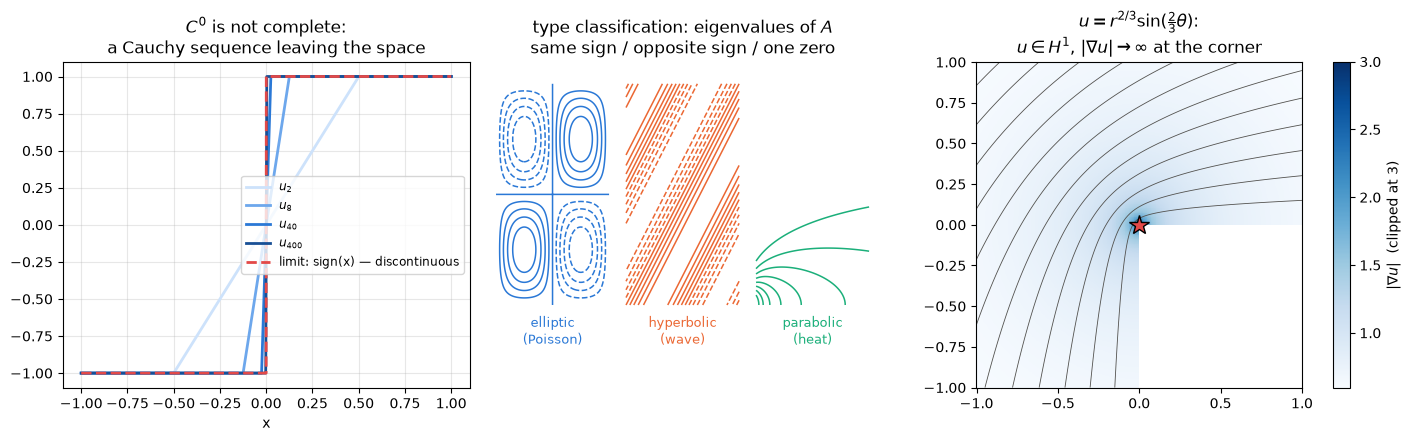

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)

# (a) the Cauchy sequence escaping C^0
t = np.linspace(-1, 1, 3000)
for n, c in zip([2, 8, 40, 400], ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95"]):
    ax[0].plot(t, u_n(t, n), color=c, lw=2, label=f"$u_{{{n}}}$")
ax[0].plot(t, sgn(t), "--", color="#e34948", lw=2, label="limit: sign(x) — discontinuous")
ax[0].set_xlabel("x"); ax[0].set_title("$C^0$ is not complete:\na Cauchy sequence leaving the space")
ax[0].legend(fontsize=8.5); ax[0].grid(alpha=0.3)

# (b) the three types
xx = np.linspace(-1, 1, 160); XX, YY = np.meshgrid(xx, xx)
for i, (lab, Z, c) in enumerate([
        ("elliptic\n(Poisson)", np.sin(np.pi*XX)*np.sin(np.pi*YY), "#2a78d6"),
        ("hyperbolic\n(wave)", np.sin(3*(XX - YY)), "#eb6834"),
        ("parabolic\n(heat)", np.exp(-((YY+1)/0.6)**2/(0.2+XX+1))/np.sqrt(0.2+XX+1), "#1baf7a")]):
    ax[1].contour(XX + 2.3*i, YY, Z, levels=9, colors=[c], linewidths=1.1)
    ax[1].text(2.3*i, -1.35, lab, ha="center", fontsize=9.5, color=c)
ax[1].set_xlim(-1.3, 5.9); ax[1].set_ylim(-1.75, 1.2); ax[1].axis("off")
ax[1].set_title("type classification: eigenvalues of $A$\nsame sign / opposite sign / one zero")

# (c) the singular solution and its gradient
n = 400
g = np.linspace(-1, 1, n); Xg, Yg = np.meshgrid(g, g)
mask = (Xg > 0) & (Yg < 0)                                 # the removed quadrant
R = np.hypot(Xg, Yg); TH = np.mod(np.arctan2(Yg, Xg), 2*np.pi)
U = np.where(mask, np.nan, R**alpha * np.sin(alpha*TH))
G = np.where(mask, np.nan, alpha * R**(alpha-1))           # |grad u|
im = ax[2].pcolormesh(Xg, Yg, np.clip(G, 0, 3), cmap="Blues", shading="auto")
ax[2].contour(Xg, Yg, U, levels=14, colors="#52514e", linewidths=0.6)
fig.colorbar(im, ax=ax[2], label=r"$|\nabla u|$  (clipped at 3)")
ax[2].plot(0, 0, "*", color="#e34948", ms=15, mec="k")
ax[2].set_aspect("equal"); ax[2].set_title(r"$u = r^{2/3}\sin(\frac{2}{3}\theta)$:"
                                           "\n" r"$u\in H^1$, $|\nabla u|\to\infty$ at the corner")
plt.show()


The $H^1$ integral converges to $3/4$ as $\varepsilon\to 0$ — **finite**, so $u\in H^1$. The $H^2$ integral grows like $\varepsilon^{-2/3}$ without bound — so $u\notin H^2$. The exponent $2/3 = \pi/\omega$ with $\omega = 3\pi/2$ is the corner's opening angle; it is exactly the number that limits the FEM convergence rate on Day 3.

## 16. Why is this important? (3) — FEM in a nutshell (slide 54)

The weak solution concept is the **basis of the finite element method**, a highly successful numerical technique for elliptic (and other) PDEs.

FEM in a nutshell: let $V_h \subset V$ be a **finite-dimensional subspace** in which the weak formulation is posed, e.g. $V_h\subset H^1_0(\Omega)$.

**Lax–Milgram implies:** $a(u_h,v) = \ell(v)\ \forall v\in V_h$ has a **unique** solution $u_h\in V_h$ — the same theorem applies verbatim to the subspace, because a closed subspace of a Hilbert space is a Hilbert space.

How can we compute $u_h$? Since $V_h$ has finite dimension, $V_h = \operatorname{span}\{\varphi_1,\dots,\varphi_N\}$ with **basis functions** $\varphi_j$. Represent $u_h = \sum_{j=1}^N z_j\varphi_j$ and insert:

$$a\Big(\sum_{j=1}^n z_j\varphi_j, v\Big) = \ell(v)\ \forall v\in V_h
\iff \sum_{j=1}^n z_j\,a(\varphi_j,\varphi_i) = \ell(\varphi_i)\ \forall i=1,\dots,n$$

$$\iff \mathbf{A}\mathbf{z} = \mathbf{b}, \qquad (A)_{i,j} = a(\varphi_j,\varphi_i),\quad (b)_i = \ell(\varphi_i)$$

**That is where Day 3 begins** → [`03-day3-pde.ipynb`](03-day3-pde.ipynb).

## 17. Summary and outlook (slide 55)

- There are **different definitions of "solutions"** of a PDE.
- **Weak solutions exist under less stringent assumptions on the data.**
- Their definition requires tools from **functional analysis** ($L^2$, $H^1$, Hilbert spaces, completeness).
- Understanding weak solutions is **helpful (but not necessary)** for understanding the finite element method.

---

### Day 2 in one table

| question | answer | slide |
|---|---|---|
| Is there a general existence theorem for PDEs? | **No** — only for specific types (unlike Peano/Picard–Lindelöf for ODEs) | 36 |
| What makes a solution "strong"? | the PDE holds pointwise; needs $u\in C^2$ and continuous data | 38 |
| Why boundary conditions? | without them solutions are not unique ($\Psi+1$, $\Psi+2x_1-3x_2+7$ all work) | 39 |
| What is well-posedness? | existence + uniqueness + **stability** (Hadamard) | 40 |
| What are the three types? | elliptic / hyperbolic / parabolic, from the eigenvalues of $A$ | 42 |
| How do we weaken the solution concept? | multiply by a test function, integrate by parts once | 44–45 |
| Which spaces? | $L^2$ (completion of $C^0$), $H^1$ (completion of $C^1$), $H^1_0$ | 46–47 |
| Who guarantees a unique weak solution? | **Lax–Milgram**: continuity + coercivity ⟹ existence, uniqueness, $\|u\|\le C_\ell/\alpha$ | 49 |
| Why bother? | discontinuous data are fine; corner singularities are captured; and it *is* the FEM | 51–54 |
